In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
%matplotlib inline

In [2]:
#LOAD DATASET
df=pd.read_csv("Mall_Customers.csv")
print("Dataset Loaded")
print("Shape:",df.shape)
display(df.head(10))

Dataset Loaded
Shape: (200, 5)


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40
5,6,Female,22,17,76
6,7,Female,35,18,6
7,8,Female,23,18,94
8,9,Male,64,19,3
9,10,Female,30,19,72


In [3]:
#DATA PREPROCESSING
print("Missing Values:")
print(df.isnull().sum())

print("\nBasic Stats:")
display(df.describe())

Missing Values:
CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

Basic Stats:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [4]:
#SELECT FEATURES & SCALE
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Features Selected & Scaled!")
print("Shape:", X_scaled.shape)

Features Selected & Scaled!
Shape: (200, 2)


C:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
[WinError 2] The system cannot find the file specified
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "C:\Users\LENOVO\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
               ^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 548, in run
    with Popen(*popenargs, **kwargs) as process:
         ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1026, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "C:\Users\LENOVO\anaconda3\Lib\subprocess.py", line 1538, in _execute_child
    hp, ht, pid, tid = _winapi.Crea

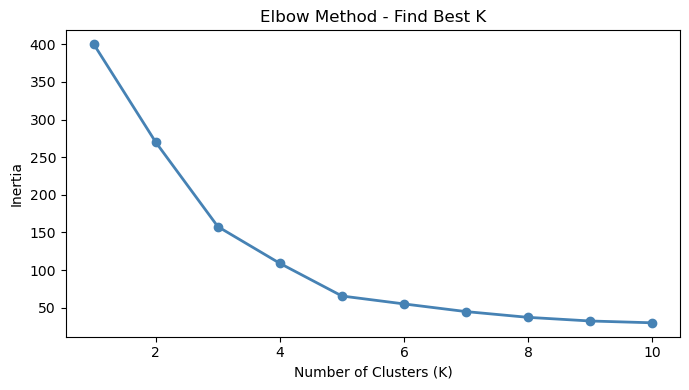

Curve bends at K=5 — so we use 5 clusters


In [5]:
#ELBOW METHOD
inertia = []

for k in range(1, 11):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(range(1, 11), inertia, marker='o', color='steelblue', linewidth=2)
ax.set_title("Elbow Method - Find Best K")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Inertia")
plt.tight_layout()
plt.show()

print("Curve bends at K=5 — so we use 5 clusters")

In [6]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

print("Clustering Done!")
print("\nCustomers per Cluster:")
print(df['Cluster'].value_counts().sort_index())

Clustering Done!

Customers per Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64


C:\Users\LENOVO\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


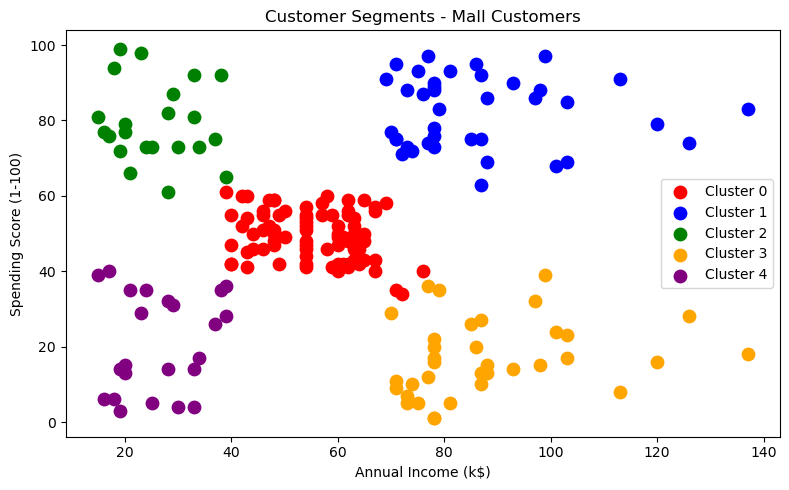

In [7]:
colors = ['red', 'blue', 'green', 'orange', 'purple']

fig, ax = plt.subplots(figsize=(8, 5))

for i in range(5):
    cluster_data = df[df['Cluster'] == i]
    ax.scatter(
        cluster_data['Annual Income (k$)'],
        cluster_data['Spending Score (1-100)'],
        label=f'Cluster {i}',
        color=colors[i],
        s=80
    )

ax.set_title("Customer Segments - Mall Customers")
ax.set_xlabel("Annual Income (k$)")
ax.set_ylabel("Spending Score (1-100)")
ax.legend()
plt.tight_layout()
plt.show()

In [8]:
insight = df.groupby('Cluster')[['Age', 'Annual Income (k$)', 'Spending Score (1-100)']].mean().round(1)
print("Cluster-wise Average Stats:")
display(insight)

Cluster-wise Average Stats:


,Age,Annual Income (k$),Spending Score (1-100)
Cluster,,,
0,42.7,55.3,49.5
1,32.7,86.5,82.1
2,25.3,25.7,79.4
3,41.1,88.2,17.1
4,45.2,26.3,20.9


In [9]:
labels = {
    0: "High Income, Low Spenders",
    1: "Low Income, Low Spenders",
    2: "Mid Income, Mid Spenders",
    3: "Low Income, High Spenders",
    4: "High Income, High Spenders"
}

print("=" * 45)
print("     CUSTOMER SEGMENTATION REPORT")
print("=" * 45)

for i in range(5):
    group = df[df['Cluster'] == i]
    print(f"\n Cluster {i} — {labels[i]}")
    print(f"  Customers   : {len(group)}")
    print(f"  Avg Income  : ${group['Annual Income (k$)'].mean():.1f}k")
    print(f"  Avg Spending: {group['Spending Score (1-100)'].mean():.1f}/100")
    print(f"  Avg Age     : {group['Age'].mean():.1f} yrs")

print("\n" + "=" * 45)

     CUSTOMER SEGMENTATION REPORT

 Cluster 0 — High Income, Low Spenders
  Customers   : 81
  Avg Income  : $55.3k
  Avg Spending: 49.5/100
  Avg Age     : 42.7 yrs

 Cluster 1 — Low Income, Low Spenders
  Customers   : 39
  Avg Income  : $86.5k
  Avg Spending: 82.1/100
  Avg Age     : 32.7 yrs

 Cluster 2 — Mid Income, Mid Spenders
  Customers   : 22
  Avg Income  : $25.7k
  Avg Spending: 79.4/100
  Avg Age     : 25.3 yrs

 Cluster 3 — Low Income, High Spenders
  Customers   : 35
  Avg Income  : $88.2k
  Avg Spending: 17.1/100
  Avg Age     : 41.1 yrs

 Cluster 4 — High Income, High Spenders
  Customers   : 23
  Avg Income  : $26.3k
  Avg Spending: 20.9/100
  Avg Age     : 45.2 yrs

